# **ETA Prediction for Last-Mile Pickup Orders using the LaDe Dataset**

### DAP391m – Data Analytics Project

### Team Members

- Nguyễn Hà Anh Khoa - SE193979
- Diệp Chung Minh - SE181950
- Nguyễn Phú Hào - SE183835

### Dataset

LaDe-P Dataset (pickup_jl.csv)

### Objective

Predict pickup ETA using machine learning techniques.

- PART 1
- ├── Step 1 Business Understanding
- ├── Step 2 Data Collection & Understanding
- └── Step 3 EDA

- PART 2
- ├── Step 4 Feature Engineering
- └── Visualization

- PART 3
- ├── Step 5 Train/Test Split
- ├── Step 6 Modeling
- ├── Step 7 Evaluation
- ├── Step 8 Hyperparameter Tuning
- └── Step 9 AI Application

- PART 4
- └── Step 10 Conclusion & Reflection

# PART 1 — Problem & Data Understanding

## 1.1 Business Understanding

### Project Title

Machine Learning-Based ETA Prediction for Last-Mile Pickup Orders using the LaDe Dataset

---

### Problem Statement

In last-mile logistics, accurately estimating pickup time is important for operational planning and service quality. However, ETA can be affected by many factors such as courier behavior, order location, and time constraints.

---

### Business Objective

Develop a machine learning model capable of predicting pickup ETA using historical order data.

---

### Success Criteria

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

---

### Dataset Description

| Item | Value |
|--------|--------|
| Dataset | LaDe-P |
| Selected File | pickup_jl.csv |
| Records | 261,801 |
| Problem Type | Regression |
| Target Variable | eta_minutes |

---

### Research Questions

**RQ1:** Which factors have the greatest impact on ETA prediction?

**RQ2:** Which machine learning model provides the best ETA prediction performance?

**RQ3:** How much can feature engineering improve ETA prediction accuracy?

---

### Step 1 Summary

The project aims to predict pickup ETA for last-mile logistics using the LaDe-P dataset. The selected dataset is pickup_jl.csv containing 261,801 records. Three research questions are proposed to investigate important ETA factors, compare machine learning models, and evaluate the impact of feature engineering.

## Data Collection & Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv(r"D:\DAP\pickup_jl.csv")

print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\DAP\\pickup_jl.csv'

### Dataset Overview

The selected dataset is pickup_jl.csv from the LaDe-P benchmark dataset.

Dataset size:
- Rows: 261,801
- Columns: 19

In [ ]:
df.head()

,order_id,region_id,city,courier_id,accept_time,time_window_start,time_window_end,lng,lat,aoi_id,aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,accept_gps_time,accept_gps_lng,accept_gps_lat,ds
0,2444404,9,Jilin,393,08-21 16:30:00,08-21 17:00:00,08-21 19:00:00,126.96093,44.41705,12,14,08-21 16:38:00,08-21 16:38:00,126.96336,44.40617,08-21 16:30:00,126.96119,44.40519,821
1,677462,9,Jilin,393,09-24 15:24:00,09-24 17:00:00,09-24 19:00:00,126.96089,44.41698,12,14,09-24 15:36:00,09-24 15:36:00,126.96353,44.40672,09-24 15:24:00,126.96204,44.40635,924
2,490122,9,Jilin,393,09-07 13:12:00,09-07 15:00:00,09-07 17:00:00,126.96090,44.41703,12,14,09-07 14:33:00,09-07 14:33:00,126.96338,44.40605,09-07 13:11:00,126.94210,44.40745,907
3,5369902,9,Jilin,6723,10-04 13:50:00,10-04 15:16:00,10-04 17:16:00,126.96077,44.41706,12,14,10-04 16:07:00,NaN,NaN,NaN,NaN,NaN,NaN,1004
4,3238782,9,Jilin,9029,10-07 08:00:00,10-07 09:00:00,10-07 11:00:00,126.96076,44.41691,12,14,10-07 09:34:00,NaN,NaN,NaN,NaN,NaN,NaN,1007


In [ ]:
df.columns.tolist()

['order_id',
 'region_id',
 'city',
 'courier_id',
 'accept_time',
 'time_window_start',
 'time_window_end',
 'lng',
 'lat',
 'aoi_id',
 'aoi_type',
 'pickup_time',
 'pickup_gps_time',
 'pickup_gps_lng',
 'pickup_gps_lat',
 'accept_gps_time',
 'accept_gps_lng',
 'accept_gps_lat',
 'ds']

### Feature Overview

The dataset contains information related to:

- Order information
- Courier information
- Geographic information
- AOI information
- Time information

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261801 entries, 0 to 261800
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           261801 non-null  int64  
 1   region_id          261801 non-null  int64  
 2   city               261801 non-null  str    
 3   courier_id         261801 non-null  int64  
 4   accept_time        261801 non-null  str    
 5   time_window_start  261801 non-null  str    
 6   time_window_end    261801 non-null  str    
 7   lng                261801 non-null  float64
 8   lat                261801 non-null  float64
 9   aoi_id             261801 non-null  int64  
 10  aoi_type           261801 non-null  int64  
 11  pickup_time        261801 non-null  str    
 12  pickup_gps_time    219748 non-null  str    
 13  pickup_gps_lng     219748 non-null  float64
 14  pickup_gps_lat     219748 non-null  float64
 15  accept_gps_time    179969 non-null  str    
 16  accept_gps_ln

In [ ]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

pickup_gps_time    42053
pickup_gps_lng     42053
pickup_gps_lat     42053
accept_gps_time    81832
accept_gps_lng     81832
accept_gps_lat     81832
dtype: int64

In [ ]:
df["accept_time"] = pd.to_datetime(df["accept_time"], format="%m-%d %H:%M:%S")
df["pickup_time"] = pd.to_datetime(df["pickup_time"], format="%m-%d %H:%M:%S")

df["eta_minutes"] = (
    df["pickup_time"] - df["accept_time"]
).dt.total_seconds() / 60

df["eta_minutes"].describe()

C:\Users\PCPV\AppData\Local\Temp\ipykernel_29620\112476202.py:1: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguious
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  df["accept_time"] = pd.to_datetime(df["accept_time"], format="%m-%d %H:%M:%S")


count    261801.000000
mean        172.142356
std         321.087582
min           0.000000
25%          45.000000
50%          92.000000
75%         160.000000
max        8599.000000
Name: eta_minutes, dtype: float64

### Target Variable Creation

The target variable eta_minutes is created as:

eta_minutes = pickup_time - accept_time

The target represents the actual time required for a courier to reach and pick up an order.

### Summary

The dataset contains 261,801 pickup orders and 19 original features. Missing values mainly occur in GPS-related attributes. A new target variable, eta_minutes, is created from the difference between pickup_time and accept_time. The dataset is suitable for a regression-based ETA prediction task.

In [ ]:
print("Tổng số dòng:", len(df))
print("Số dòng có ETA:", df["eta_minutes"].notnull().sum())
print("Số dòng thiếu ETA:", df["eta_minutes"].isnull().sum())

Tổng số dòng: 261801
Số dòng có ETA: 261801
Số dòng thiếu ETA: 0


# EDA data


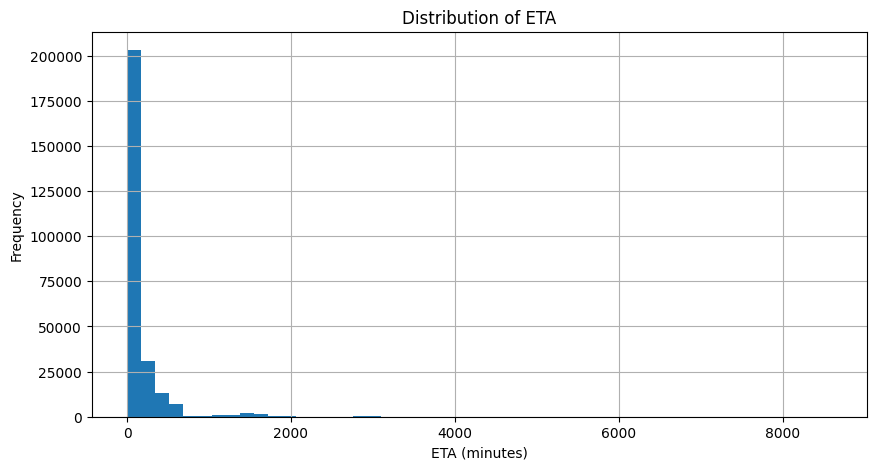

In [ ]:
import matplotlib.pyplot as plt

df["eta_minutes"].hist(
    bins=50,
    figsize=(10,5)
)

plt.xlabel("ETA (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of ETA")
plt.show()

In [ ]:
df["eta_minutes"].describe(
    percentiles=[0.9,0.95,0.99]
)

count    261801.000000
mean        172.142356
std         321.087582
min           0.000000
90%         361.000000
95%         535.000000
99%        1643.000000
max        8599.000000
Name: eta_minutes, dtype: float64

### ETA Distribution

The ETA distribution is highly right-skewed. Most pickup orders are completed within a relatively short time, while a small number of orders require significantly longer pickup times. The presence of large ETA values indicates potential outliers.

### Boxplot Outlier


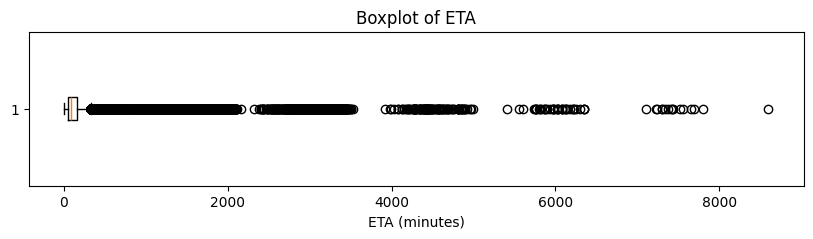

In [ ]:
plt.figure(figsize=(10,2))

plt.boxplot(df["eta_minutes"].dropna(),
        vert=False)

plt.title("Boxplot of ETA")
plt.xlabel("ETA (minutes)")
plt.show()

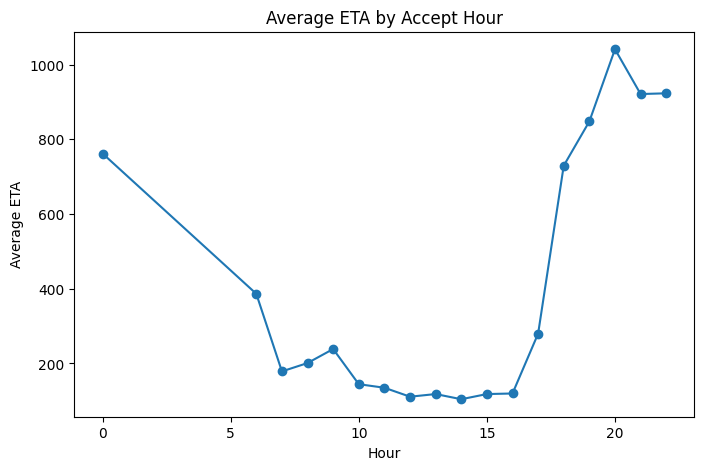

In [ ]:
df["accept_hour"] = df["accept_time"].dt.hour

hourly_eta = df.groupby(
    "accept_hour"
)["eta_minutes"].mean()

hourly_eta.plot(
    figsize=(8,5),
    marker="o"
)

plt.title("Average ETA by Accept Hour")
plt.xlabel("Hour")
plt.ylabel("Average ETA")
plt.show()

### ETA with AOI

In [ ]:
aoi_eta = df.groupby(
    "aoi_type"
)["eta_minutes"].mean()

aoi_eta.sort_values()

aoi_type
9      41.800000
5      86.000000
13    133.417582
12    138.586648
3     145.887387
7     157.773544
4     160.737600
14    171.207930
10    171.595013
1     173.350431
0     201.456716
11    203.341463
2     214.328358
8     273.923077
Name: eta_minutes, dtype: float64

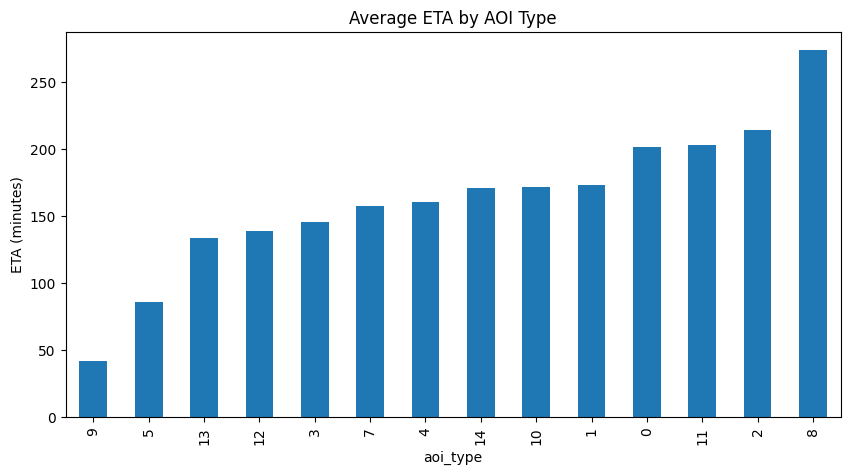

In [ ]:
aoi_eta.sort_values().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average ETA by AOI Type")
plt.ylabel("ETA (minutes)")
plt.show()

### ETA by AOI Type

Different AOI types exhibit different pickup times, indicating that geographical and functional area characteristics affect courier efficiency.

In [ ]:
courier_eta = df.groupby(
    "courier_id"
)["eta_minutes"].mean()

courier_eta.describe()

count     665.000000
mean      172.758292
std       228.663632
min         1.000000
25%        77.500000
50%       128.000000
75%       190.285714
max      2943.000000
Name: eta_minutes, dtype: float64

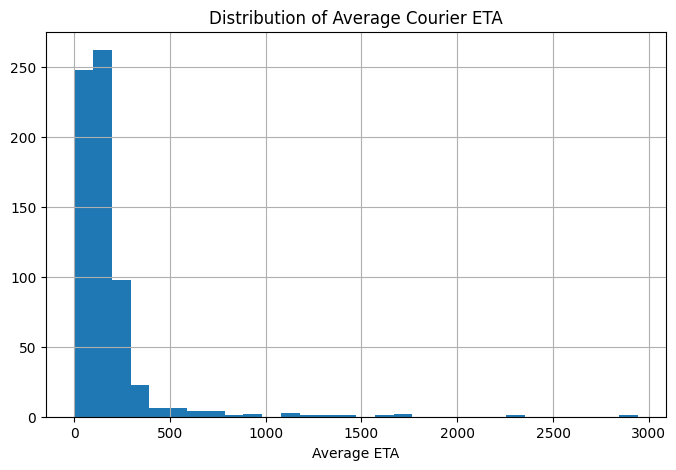

In [ ]:
courier_eta.hist(
    bins=30,
    figsize=(8,5)
)

plt.title("Distribution of Average Courier ETA")
plt.xlabel("Average ETA")
plt.show()

### ETA by Courier

Courier performance varies considerably. Some couriers consistently complete pickups faster than others, suggesting that courier behavior is an important predictive feature.

# Correlation matrix

In [ ]:
df["accept_day"] = df["accept_time"].dt.day
df["accept_month"] = df["accept_time"].dt.month
df["day_of_week"] = df["accept_time"].dt.dayofweek

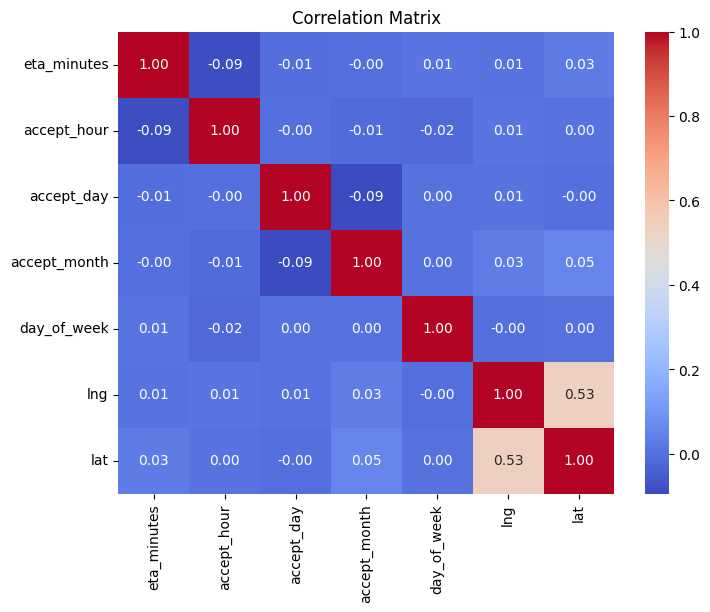

In [ ]:
import seaborn as sns

numeric_cols = [
    "eta_minutes",
    "accept_hour",
    "accept_day",
    "accept_month",
    "day_of_week",
    "lng",
    "lat"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix indicates weak linear relationships between individual features and ETA. This suggests that ETA prediction is a complex and nonlinear problem influenced by multiple interacting factors. Therefore, advanced machine learning models such as XGBoost and LightGBM are more suitable than simple linear models.

### Summary

EDA reveals that ETA exhibits a highly right-skewed distribution with several outliers. Temporal features, geographic information, AOI characteristics, and courier behavior all appear to influence pickup efficiency and are therefore useful for model development.

# Features Engineering

In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

pickup_gps_time    42053
pickup_gps_lng     42053
pickup_gps_lat     42053
accept_gps_time    81832
accept_gps_lng     81832
accept_gps_lat     81832
dtype: int64

### Tạo Features Gps

In [ ]:
df["has_accept_gps"] = (
    df["accept_gps_lng"].notnull()
).astype(int)

df["has_pickup_gps"] = (
    df["pickup_gps_lng"].notnull()
).astype(int)

In [ ]:
df[[
    "has_accept_gps",
    "has_pickup_gps"
]].head()

,has_accept_gps,has_pickup_gps
0,1,1
1,1,1
2,1,1
3,0,0
4,0,0


### Tạo features time

In [ ]:
df["accept_hour"] = df["accept_time"].dt.hour

df["accept_day"] = df["accept_time"].dt.day

df["accept_month"] = df["accept_time"].dt.month

df["day_of_week"] = df["accept_time"].dt.dayofweek

In [ ]:
df[[
    "accept_hour",
    "accept_day",
    "accept_month",
    "day_of_week"
]].head()

,accept_hour,accept_day,accept_month,day_of_week
0,16,21,8,1
1,15,24,9,0
2,13,7,9,4
3,13,4,10,3
4,8,7,10,6


### Features Courier Experiance

In [ ]:
df["courier_order_count"] = (
    df.groupby("courier_id")
      ["order_id"]
      .transform("count")
)

# Xử lí outlier

In [ ]:
upper = df["eta_minutes"].quantile(0.99)

print("99th percentile:", upper)

99th percentile: 1643.0


In [ ]:
df_clean = df[
    df["eta_minutes"] <= upper
].copy()

print(df_clean.shape)

(259184, 27)


### Outlier Removal

Extreme ETA values above the 99% were removed to reduce noise and improve model stability.

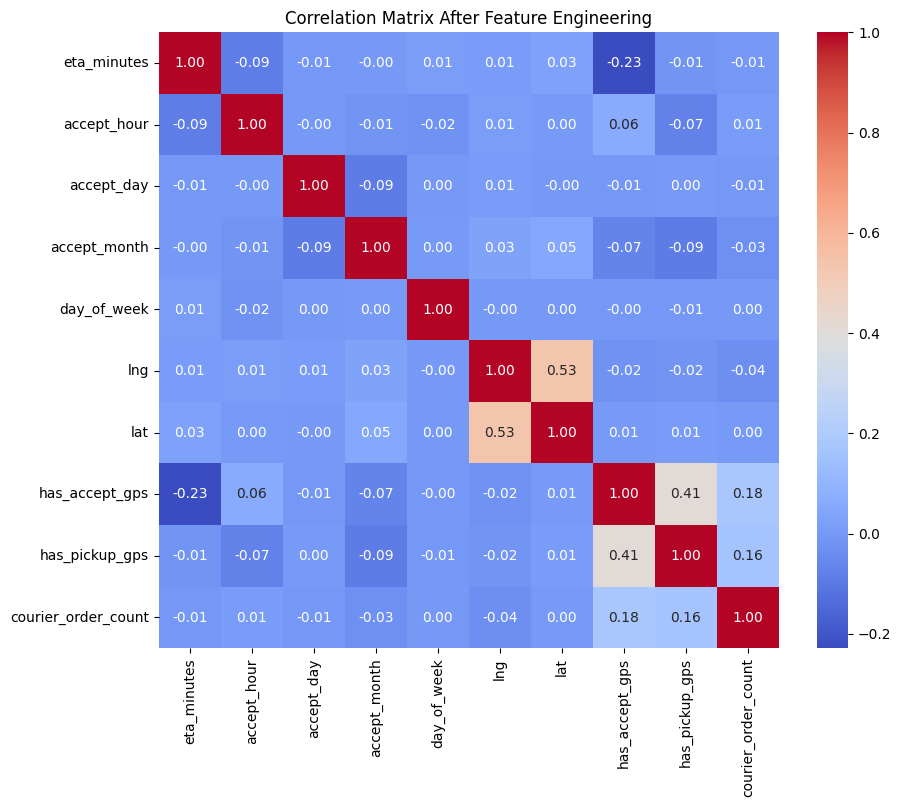

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    "eta_minutes",
    "accept_hour",
    "accept_day",
    "accept_month",
    "day_of_week",
    "lng",
    "lat",
    "has_accept_gps",
    "has_pickup_gps",
    "courier_order_count"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix After Feature Engineering")

plt.show()

### Lọc features cho model

In [ ]:
# Step 4.6 — Select features for modeling

categorical_features = [
    "courier_id",
    "aoi_type",
    "region_id"
]

numerical_features = [
    "accept_hour",
    "accept_day",
    "accept_month",
    "day_of_week",
    "lng",
    "lat",
    "has_accept_gps",
    "has_pickup_gps",
    "courier_order_count"
]

target = "eta_minutes"

selected_features = categorical_features + numerical_features

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Target:", target)
print("Total selected features:", len(selected_features))


Categorical features: ['courier_id', 'aoi_type', 'region_id']
Numerical features: ['accept_hour', 'accept_day', 'accept_month', 'day_of_week', 'lng', 'lat', 'has_accept_gps', 'has_pickup_gps', 'courier_order_count']
Target: eta_minutes
Total selected features: 12


In [ ]:
# Create final modeling dataset

model_df = df_clean[selected_features + [target]].dropna().copy()

X = model_df[selected_features]
y = model_df[target]

print("Model dataset shape:", model_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Model dataset shape: (259184, 13)
X shape: (259184, 12)
y shape: (259184,)


In [ ]:
X.head()

,courier_id,aoi_type,region_id,accept_hour,accept_day,accept_month,day_of_week,lng,lat,has_accept_gps,has_pickup_gps,courier_order_count
0,393,14,9,16,21,8,1,126.96093,44.41705,1,1,1852
1,393,14,9,15,24,9,0,126.96089,44.41698,1,1,1852
2,393,14,9,13,7,9,4,126.96090,44.41703,1,1,1852
3,6723,14,9,13,4,10,3,126.96077,44.41706,0,0,38
4,9029,14,9,8,7,10,6,126.96076,44.41691,0,0,18


# Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (207347, 12)
X_test shape: (51837, 12)
y_train shape: (207347,)
y_test shape: (51837,)


In [ ]:
print("Train target statistics:")
print(y_train.describe())

print("\nTest target statistics:")
print(y_test.describe())

Train target statistics:
count    207347.000000
mean        149.428359
std         213.830017
min           0.000000
25%          44.000000
50%          91.000000
75%         156.000000
max        1643.000000
Name: eta_minutes, dtype: float64

Test target statistics:
count    51837.000000
mean       152.195903
std        217.448360
min          0.000000
25%         45.000000
50%         91.000000
75%        158.000000
max       1643.000000
Name: eta_minutes, dtype: float64


# Step 6 — Data Modelling

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Model libraries loaded.")

Model libraries loaded.


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [ ]:
model_catalogue = {
    "Dummy Mean": DummyRegressor(strategy="mean"),

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.1),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    )
}

print(f"{len(model_catalogue)} models defined.")

7 models defined.


In [ ]:
trained_pipelines = {}

for name, model in model_catalogue.items():
    print(f"Training {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    trained_pipelines[name] = pipe

    print(f"✓ {name} trained.")

print("\nAll models trained successfully.")

Training Dummy Mean...
✓ Dummy Mean trained.
Training Linear Regression...
✓ Linear Regression trained.
Training Ridge...
✓ Ridge trained.
Training Lasso...
✓ Lasso trained.
Training Random Forest...
✓ Random Forest trained.
Training XGBoost...
✓ XGBoost trained.
Training LightGBM...
✓ LightGBM trained.

All models trained successfully.


### Step 6 Summary

Multiple regression models were trained for ETA prediction, including Dummy Mean, Linear Regression, Ridge, Lasso, Random Forest, XGBoost, and LightGBM. A shared preprocessing pipeline was used to encode categorical features and pass numerical features consistently into each model.

# STEP 7 - EValuate Model

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [ ]:
results = []

for name, pipe in trained_pipelines.items():

    prediction = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE"
)



d:\DIEP CHUNG MINH\0. FPT University\Pycharm Project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
results_df = results_df.round(2)

results_df

,Model,MAE,RMSE,R2
6,LightGBM,108.69,192.68,0.21
4,Random Forest,107.97,194.68,0.20
5,XGBoost,110.15,195.40,0.19
2,Ridge,119.08,210.02,0.07
1,Linear Regression,119.57,210.47,0.06
3,Lasso,119.87,210.78,0.06
0,Dummy Mean,121.31,217.46,-0.00


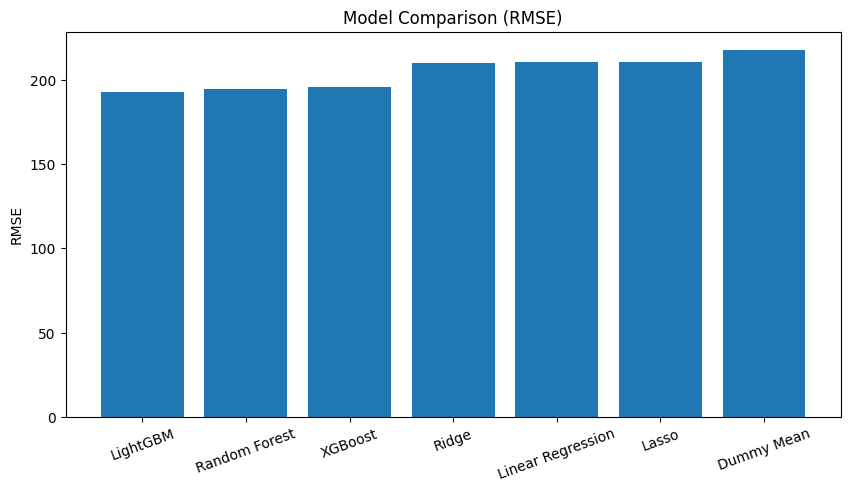

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xticks(rotation=20)

plt.ylabel("RMSE")

plt.title("Model Comparison (RMSE)")

plt.show()

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

best_pipeline = trained_pipelines[
    best_model_name
]

print("Best model:", best_model_name)

Best model: LightGBM


### Summary

All trained models were evaluated on the test dataset using MAE, RMSE, and R². The models were ranked by RMSE, and the best-performing model was selected for further optimization and deployment.

# Step 8 - Hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

#### pipeline LightGBM

In [ ]:
lgbm_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        random_state=42,
        verbosity=-1
    ))
])

#### Tạo tham số

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__num_leaves": [31, 63, 127],
    "model__max_depth": [-1, 6, 10]
}

In [ ]:
search = RandomizedSearchCV(
    estimator=lgbm_tuning_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [-1, 6, ...], 'model__n_estimators': [100, 200, ...], 'model__num_leaves': [31, 63, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

In [ ]:
print("Best parameters:")
print(search.best_params_)

print("Best CV RMSE:")
print(-search.best_score_)

Best parameters:
{'model__num_leaves': 63, 'model__n_estimators': 200, 'model__max_depth': -1, 'model__learning_rate': 0.05}
Best CV RMSE:
188.42383071595054


In [ ]:
best_tuned_pipeline = search.best_estimator_

tuned_pred = best_tuned_pipeline.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)

tuned_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_pred)
)

tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned LightGBM Evaluation")
print("MAE:", round(tuned_mae, 2))
print("RMSE:", round(tuned_rmse, 2))
print("R2:", round(tuned_r2, 4))

Tuned LightGBM Evaluation
MAE: 107.27
RMSE: 191.1
R2: 0.2276


d:\DIEP CHUNG MINH\0. FPT University\Pycharm Project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
before_tuning = results_df[
    results_df["Model"] == "LightGBM"
].iloc[0]

comparison_df = pd.DataFrame({
    "Version": ["Before Tuning", "After Tuning"],
    "MAE": [
        before_tuning["MAE"],
        round(tuned_mae, 2)
    ],
    "RMSE": [
        before_tuning["RMSE"],
        round(tuned_rmse, 2)
    ],
    "R2": [
        before_tuning["R2"],
        round(tuned_r2, 4)
    ]
})

comparison_df

,Version,MAE,RMSE,R2
0,Before Tuning,108.69,192.68,0.2100
1,After Tuning,107.27,191.10,0.2276


# Demo

In [ ]:
final_pipeline = best_tuned_pipeline

print("Final model selected: Tuned LightGBM")

Final model selected: Tuned LightGBM


In [ ]:
import joblib
import os

os.makedirs("app_model", exist_ok=True)

joblib.dump(
    final_pipeline,
    "app_model/best_eta_prediction_pipeline.pkl"
)

print("Model saved to app_model/best_eta_prediction_pipeline.pkl")

Model saved to app_model/best_eta_prediction_pipeline.pkl


In [ ]:
loaded_model = joblib.load("app_model/best_eta_prediction_pipeline.pkl")

sample_input = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_input)[0]

print("Sample input:")
display(sample_input)

print("Predicted ETA:", round(prediction, 2), "minutes")
print("Actual ETA:", y_test.iloc[0], "minutes")

Sample input:


d:\DIEP CHUNG MINH\0. FPT University\Pycharm Project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,courier_id,aoi_type,region_id,accept_hour,accept_day,accept_month,day_of_week,lng,lat,has_accept_gps,has_pickup_gps,courier_order_count
15757,7634,14,11,13,24,9,0,127.32899,43.71757,1,1,679


Predicted ETA: 53.68 minutes
Actual ETA: 44.0 minutes
